In [107]:
import json
import os
from PIL import Image
import pandas as pd
#import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter
from collections import defaultdict
import random
import shutil
#from torchvision import transforms
from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

### 1. Geschaeftsverstaendnis 

#### 1.1 Ausgangslage und Problemstellung

Das Wolframinertgas-Schweißen (WIG bzw. TIG) ist ein in der Automobil- und Flugzeugbranche weit verbreitetes Verfahren für das dauerhafte Verbinden verschiedenster Metalle. Die Qualitaet ist fuer die Sicherheit von entscheidender Bedeutung. 

Die Kontrolle dieser Schweißnaehte erfolgt entweder manuell ueber Pruefpersonal, das speziell auf diese Thematik geschult wurde oder zerstoerungsfreie Prüfverfahren, worunter u.a. Ultraschall- oder Röntgenverfahren fallen. Die erste Variante ist von subjektiven Einflüssen geprägt, während die maschinellen Lösungen ebenfalls teuer in der Anschaffung sind und Fehler auch erst im Nachgang, am Ende der Produktionslinie entdeckt werden können.

#### 1.2 Projektziel

Das Ziel dieses Projekts soll die Erprobung eines automatisierten Erkennungssystems zur Klassifikation von Schweißnahtfelern sein. Die mit einer High-Dynamic-Range-Kamera (HDR) aufgenommenen Bilder sollen im realen Fall korrekte Zuweisungen der Klassen ermöglichen, wobei auf einen hohen Recall zu achten ist sowie eine hohe Precision, die Fehlalarme in einer Produktionslinie bedueten. 

In [108]:
class DatasetManager:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        # Zuweisung der Verzeichnispfade
        self.train_dir = self.data_dir / "train"
        self.test_dir = self.data_dir / "test"
        self.train_data = None
        self.test_data = None
        self.train_class_counts = None
        self.test_class_counts = None

    # Uebersicht der Verzeichnisstruktur und Inhalte anzeigen
    def show_structure(self):
        print("=== Verzeichnisstruktur ===")
        print(f"Data directory: {self.data_dir}")
        print(f'Inhalt des Verzeichnisses {self.data_dir}: {os.listdir(self.data_dir)}')
        # Iteration ueber die unterschiedlichen Verzeichnisse zu train und test
        for label, path in [("Testverzeichnis", self.test_dir), ("Trainverzeichnis", self.train_dir)]:
            print(f"\n{label}: {path}")
            print(f"Inhalt des Verzeichnisses {label}: {os.listdir(path)}")
        return [self.test_dir, self.train_dir]

    def _load_json(self, json_path):
        # Einlesen der Json files mit den Dateinamen sowie zugehoerigen Label
        with open(json_path, 'r') as f:
            data = json.load(f)
        # Ausgabe der Menge an gespeicherten Elementen in Json und Zaehler der Label
        print(f'\nGeladene Bilddaten in {json_path}: {len(data)}')
        class_counts = Counter(data.values())
        print(f'Klassenverteilung in {json_path}: {sorted(class_counts.items())}')

        return data, class_counts

    # Zaehlen der Bilder im Datensatz
    def count_split_images(self, split):
        # Generieren des Dateipfads des Split
        directory = self.data_dir / split
        images = []
        # Zaehler der Haeufigkeit der verschiedenen Datentypen (suffix)
        formats = Counter()
        # Verzeichnisbaeume werden rekursiv durchlaufen und in einem 3-Tupel zurueckgegeben
        for root, dirs, files in os.walk(directory):
            for file in files:
                # Die Enden werden zusammengefasst, deren Punkt entfernt und dem dict 'formats' als Zaehler uebergeben
                ext = Path(file).suffix.lower().lstrip('.')
                formats[ext] += 1
                # Fuer jede gefundene Endung wird der Zaehler um 1 erhoeht
                if ext in {"png", "jpg", "jpeg"}:
                    images.append(os.path.join(root, file))

        print(f"Gefundene Formate in {split}: {dict(formats)}")
        return len(images)

    def image_size_info(self, split):
        print('=== Groesse der ersten 10 Bilder im Trainings-Datensatz ===')
        # Zusammenstellung des Speicherort für die Test- oder Trainings-Split
        if split == 'train': 
            split = self.train_dir
        else: 
            split = self.test_dir
        sizes = []
        # Slicing bis zu den ersten 10 Elementen , die in self.train_data gepseichert sind
        for image_name in list(self.train_data.keys())[:10]:
            # Bildpfad erstellen des zu bewertenden Bildes
            img_path = split / image_name
            img = Image.open(img_path)
            sizes.append(img.size)
            print(f'    {image_name}: {img.size}')

    # Laden der Einzelsplits von Test und Training
    def load_split(self, split):
        json_path = self.data_dir / split / f"{split}.json"
        data, class_counts = self._load_json(json_path)
        # Zuweisung der Trainigsdaten und Testdaten zu den Variablen
        # train_data und test_data enthalten je den Namen der Datei und das Label aus der .json Datei
        if split == "train":
            self.train_data, self.train_class_counts = data, class_counts
        elif split == "test":
            self.test_data, self.test_class_counts = data, class_counts
        else:
            raise ValueError(f"Unbekannter Split: {split}")
        #return data, class_counts
    
    '''Hauptfunktion um die Daten aus den Ordnern aufzurufen und in die Variablen einzuspeichern'''
    def load_all(self):
        print('\n===Trainings- und Testset (Inhalt)===')
        self.load_split("train")
        
        self.load_split("test")

        print('\n===Bilddateien pro Split===')
        train_count = self.count_split_images("train")
        print(f"Train Bilder: {train_count}")
        
        test_count = self.count_split_images("test")
        print(f"Test Bilder: {test_count}")
        return self.train_data, self.test_data

    # Funktion zur Reduktion des Datensatzes auf eine einheitliche Menge der verschiedenen Klassen
    def create_balanced_subset(self, output_dir, split, samples_per_label=400, seed=42, copy_files=True, target_size=None):
        # Festlegung des Ursprungverzeichnis, wovon später aus in das output_dir Bilddaten kopiert werden
        if split == 'train':
            source_img_dir = self.train_dir
            data = self.train_data 
        elif split == 'test': 
            source_img_dir = self.test_dir
            data = self.test_data
        output_dir = Path(output_dir)
        subset_out_dir = output_dir / split
        # Erzeugen des neuen Verzeichnis als Speicherort (Hauptverzeichnis und Unterverzeichnis 'train' oder 'test')
        # parents = True erzeugt automatisch nicht existente Ordnerstrukturen, um Fehler vorzubeugen
        subset_out_dir.mkdir(parents=True, exist_ok=True)
        random.seed(seed)

        by_label = defaultdict(list)

        # Gruppierung der Bilder nach deren zugehoerigen Labels in by_label
        for rel_path, label in data.items():
            #source = source_img_dir / rel_path
            by_label[label].append(rel_path)
        # Festlegung der Zahl initial vorhandener Dateien im Datensatz für den Abgleich nach der Reduktion
        stats_before = []
        for label, paths in sorted(by_label.items()):
            stats_before.append({'label': label, 'Vorhandene Bilder': len(paths)})

        # Schritt zur Intervention, sofern eine Sample-Zahl gewählt wird, die die Zahl der eigentlichen Dateien ueberschreitet
        if samples_per_label is not None:
            too_small = {}
            for label, paths in by_label.items():
                if len(paths) < samples_per_label:
                    too_small[label] = len(paths)
            if too_small:
                raise ValueError(f"Diese Labels haben zu wenige Bilder für {samples_per_label} pro Label: {too_small}")

        # Entnahme einer zufaelligen Auswahl an Dateien aus dem gewählten Split
        selected = {} 
        for label, paths in by_label.items():
            # Unterscheidung, ob ein Datensatz auf eine einheitliche Menge reduziert werden soll oder nicht
            # Jede Klasse wird in der Schleife ein Mal durchlaufen (1 bis 6)
            if samples_per_label is not None:
                # Entnahme der zuvor k definierten Werten
                chosen = random.sample(paths, k = samples_per_label)
            else: 
                chosen = paths
            # Strukturierung der Datei so, dass den Bilddateien einzeln die Label zugewiesen werden
            for rel_path in chosen: 
                selected[rel_path] = label # Speichern der Dateinamen wie in der Ursprungsdatei, so dass die Verarbeitung der Daten beibehalten wird
        # Starten des Kopiervorgangs in das neue Verzeichnis
        if copy_files:
            copied = 0
            for rel_path in selected.keys():
                # Zusammensetzung der originalen Dateipfade der Originaldateien
                src = source_img_dir / rel_path # source bestimmt nur den uebergeordneten Ordner, waehrend rel_path die Unterordnerstruktur darstellt
                destination = subset_out_dir  / rel_path
                # Erzeugen des neuen Dateipfades, indem die alten Ordnerbezeichnungen ueberonmmen werden
                # .parent ermittelt den Pfad der übergeordneten Ordner, in dem die Datei liegen soll (in .json abgelegte Namen beinhalten bereits die Ordnerstruktur. Beispiel: "170906-144958-Al 2mm/frame_01150.png" im Ordner "170906-144958-Al 2mm")
                # parents = True erzeugt automatisch nicht existente Ordnerstrukturen, um Fehler vorzubeugen
                destination.parent.mkdir(parents=True, exist_ok=True)

                # Eingabe eines Resampling getätigt oder nicht?
                if target_size is not None:
                    img = Image.open(src)
                    # LANCZOS als Methode zum Resampling von Bildern mit der besten Qualität --> https://www.geeksforgeeks.org/python/python-pil-image-resize-method/
                    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
                    # Neue Bilddateien werden direkt in den neuen Speicherort abgelegt
                    img_resized.save(destination)
                # Metadaten werden uebernommen. Kopieren jeder Bilddatei aus selected
                else: 
                    shutil.copy2(src = src, dst = destination)
                copied += 1
            status_text = f"kopiert & verkleinert auf {target_size}" if target_size else "kopiert"
            print(f'Bilder {status_text}: {copied} nach: {subset_out_dir}')
        # Erstellen der .json-Datei. Selected speichert die Daten in path: label
        output_json = subset_out_dir / f'{split}.json'
        # Beschreiben der neuen json-Datei
        with open(output_json, 'w') as f: 
            json.dump(selected, f, indent=2)
        label_counts = Counter(selected.values())
        # Darstellung der Anzahl an Werten im neuen Verzeichnis
        stats_after = []
        for label in sorted(label_counts):
            stats_after.append({
                'label': label,
                'Gewaehlte Bilder': label_counts[label]
            })

        # Umwandlung in DataFrame für bessere Darstellung als Tabelle in der Ausgabe
        df_before = pd.DataFrame(stats_before).sort_values("label").reset_index(drop=True)
        df_after = pd.DataFrame(stats_after).sort_values("label").reset_index(drop=True)
        df_stats = df_before.merge(df_after, on="label", how="left")


        print(f"Subset-JSON gespeichert: {output_json}")
        #print(f"Fehlende Dateien im Originaldatensatz: {len(missing_files)}")
        print(f"Gesamtzahl im Subset: {len(selected)}")

        display(df_stats)


        return selected, df_stats
        
    def plot_distribution(self):

        fig, axes = plt.subplots(2, 1, figsize=(8, 8))
        titles = ["Trainingsdaten", "Testdaten"]
        tick_positions = [0, 1, 2, 3, 4, 5]
        tick_labels = ['Good Weld (0)', 'Burn Through (1)', 'Contamination (2)', 'Lack of Fusion (3)', 'Misalignment (4)', 'Lack of Penetration (5)']
        
        index = 0 
        
        for data in [self.train_class_counts.values(), self.test_class_counts.values()]:
            ax = axes[index] 
            ax.set_title(titles[index], fontsize=10)
            ax.bar(self.train_class_counts.keys(), data, edgecolor='black')
            ax.set_ylabel('Häufigkeit der Label im Datensatz')
            
            # Ticks setzen
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, rotation=45, ha='right')
            
            index += 1 
            
        fig.suptitle('Verteilung der Datensätze')
        fig.supxlabel('Label')
        fig.tight_layout()
        plt.show()



### 2. Datenverständnis

In dieser Phase werden die Bilddaten strukturell und visuell analysiert. Das umfasst das legen einer Basis für die folgende Bearbeitung mittels der automatisierten Prozessen für die Modellbildung. 

#### 2.1 Datenumfang und Klassenverteilung

Der genutzte Datensatz besteht aus 26.666 Trainings- und 6.588 Test-Daten. Dieser wurde dem Handling geschuldet auf jeweils 2400 bzw. 1200 Bilddaten verkleinert. Diese Daten verteilen sich auf die 6 Fehlerklassen (Good Weld, Burn Through, Contamination, Lack of Fusion, Misalignment, Lack of Penetration). So soll eine Verzerrung zugunsten einer überrepräsentierten Klasse vermieden werden. 

#### 2.2 Bildstruktur und Metadaten

Die stichprobenartige Analyse der Bilddateien liefert die folgenden Eigenschaften der Eingangsdaten: 

* **Auflösung:** Die Originalbilder liegen in einer Auflösung von $800 \times 974$ Pixeln vor.
* **Farbmodus:** Der Modus ist `L` (Luminance). Das heißt, dass die Bilder im Graustufenformat vorliegen, wodurch die Klassifikation anhand nur der Lichtwerte, ohne Farbinformationen, erfolgt.

#### 2.3 Datenstruktur

Die Bilddaten sind in Ordnern organisiert, die den einzelnen Schweißversuchen entsprechen. Innerhalb der Ordner sind die Frames der Aufnahmen zu finden. Die Bilder sind ähneln sich entsprechend untereinander. 

#### 2.4 Visuelle Inspektion der Schweißnahtfehler

* **Good Weld (0):**            Eine gleichmäßige Schweißnaht.
* **Burn Through (1):**         Ein deutliches Loch in der Naht durch zu viel Hitzeeintrag.
* **Contamination (2):**        Flecken und Unreinheiten im Schmelzbereich.
* **Lack of Fusion (3):**       Bindefehler, bei denen die Kanten nicht richtig verschmolzen sind.
* **Misalignment (4):**         Ein Versatz zwischen den zu verschweißenden Blechen.
* **Lack of Penetration (5):**  Ungenügende Durchdringung der Schweißnaht zur Rückseite.

In [109]:
#data_dir = Path('/data')
data_dir = Path('/data/al5083_subset_balanced_2400')
orig_set = DatasetManager(data_dir)
orig_set.show_structure()
orig_set.load_all(); 


=== Verzeichnisstruktur ===
Data directory: /data/al5083_subset_balanced_2400
Inhalt des Verzeichnisses /data/al5083_subset_balanced_2400: ['test', 'train']

Testverzeichnis: /data/al5083_subset_balanced_2400/test
Inhalt des Verzeichnisses Testverzeichnis: ['170904-150144-Al 2mm-part2', '170904-152301-Al 2mm-part2', '170904-154202-Al 2mm-part1', '170904-155610-Al 2mm', '170905-112213-Al 2mm', '170906-104925-Al 2mm', '170906-113317-Al 2mm-part1', '170906-143512-Al 2mm-part1', '170906-143512-Al 2mm-part2', '170906-151724-Al 2mm-part1', '170906-153326-Al 2mm-part3', '170906-155007-Al 2mm-part1', '170906-155007-Al 2mm-part2', '170913-154448-Al 2mm', 'test.json']

Trainverzeichnis: /data/al5083_subset_balanced_2400/train
Inhalt des Verzeichnisses Trainverzeichnis: ['170815-133921-Al 2mm', '170815-134756-Al 2mm', '170904-112347-Al 2mm', '170904-113012-Al 2mm-part1', '170904-113012-Al 2mm-part2', '170904-115503-Al 2mm', '170904-115959-Al 2mm', '170904-141232-Al 2mm-part1', '170904-141232-Al 2

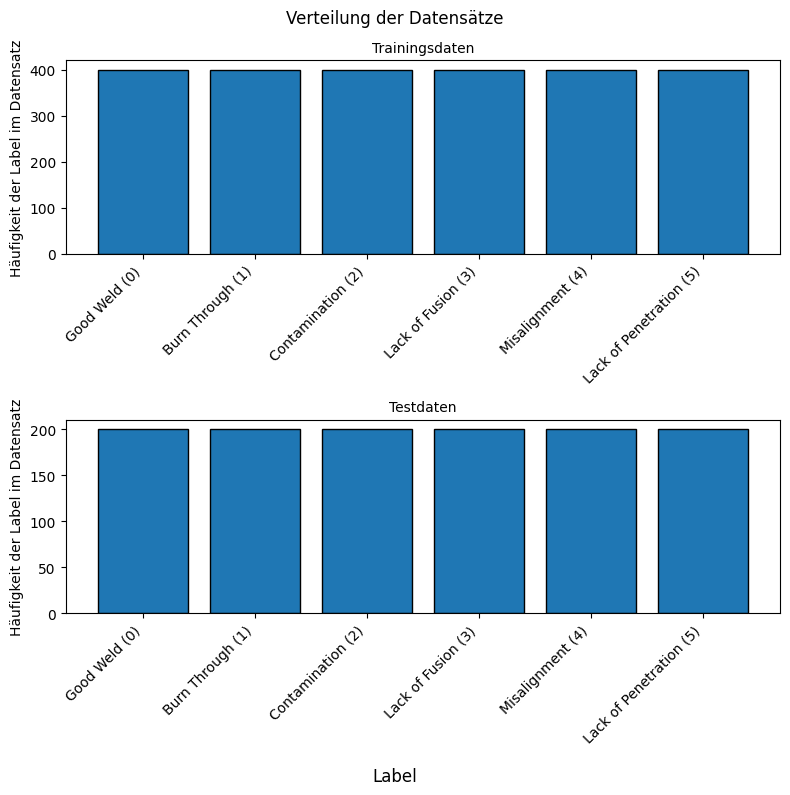

In [110]:
orig_set.plot_distribution()


In [111]:
for filename, label in orig_set.train_data.items():
    print(filename, label)

print(orig_set.train_dir);

170906-144958-Al 2mm/frame_01345.png 1
170906-144958-Al 2mm/frame_00135.png 1
170906-113317-Al 2mm-part3/frame_00680.png 1
170906-144958-Al 2mm/frame_00884.png 1
170906-144958-Al 2mm/frame_01364.png 1
170906-144958-Al 2mm/frame_00714.png 1
170906-144958-Al 2mm/frame_00258.png 1
170906-144958-Al 2mm/frame_00510.png 1
170906-144958-Al 2mm/frame_01396.png 1
170906-144958-Al 2mm/frame_01407.png 1
170906-144958-Al 2mm/frame_01320.png 1
170906-144958-Al 2mm/frame_00551.png 1
170906-144958-Al 2mm/frame_01416.png 1
170906-144958-Al 2mm/frame_00329.png 1
170906-144958-Al 2mm/frame_00255.png 1
170906-144958-Al 2mm/frame_01387.png 1
170906-144958-Al 2mm/frame_01150.png 1
170906-144958-Al 2mm/frame_01117.png 1
170906-144958-Al 2mm/frame_00547.png 1
170906-144958-Al 2mm/frame_01003.png 1
170906-144958-Al 2mm/frame_01480.png 1
170906-144958-Al 2mm/frame_01926.png 1
170906-144958-Al 2mm/frame_01019.png 1
170906-113317-Al 2mm-part3/frame_00663.png 1
170906-144958-Al 2mm/frame_01276.png 1
170906-144958

Shape: (974, 800)
Modus: L
  170905-115602-Al 2mm/frame_00909.png (Label: 0) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-144958-Al 2mm/frame_01345.png (Label: 1) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170904-112347-Al 2mm/frame_01757.png (Label: 2) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-150801-Al 2mm/frame_01013.png (Label: 3) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170904-141730-Al 2mm-part3/frame_00402.png (Label: 4) - Size: (800, 974)
Shape: (974, 800)
Modus: L
  170906-153326-Al 2mm-part1/frame_00283.png (Label: 5) - Size: (800, 974)


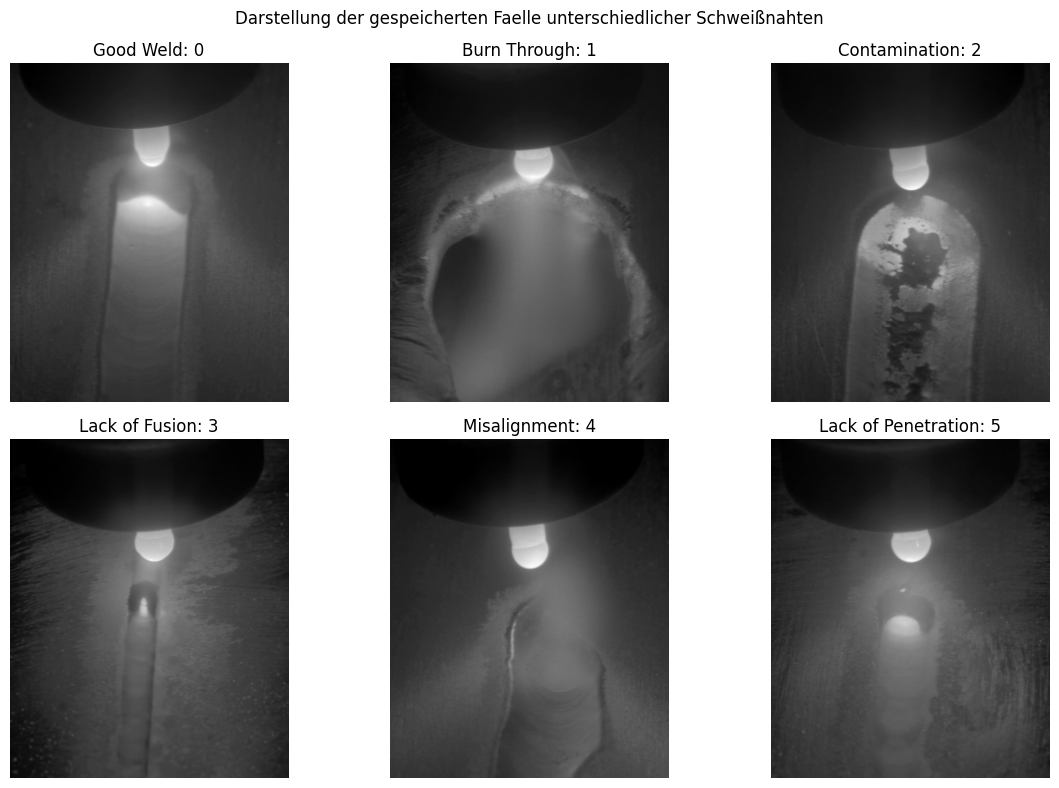

=== Groesse der ersten 10 Bilder im Trainings-Datensatz ===
    170906-144958-Al 2mm/frame_01345.png: (800, 974)
    170906-144958-Al 2mm/frame_00135.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00680.png: (800, 974)
    170906-144958-Al 2mm/frame_00884.png: (800, 974)
    170906-144958-Al 2mm/frame_01364.png: (800, 974)
    170906-144958-Al 2mm/frame_00714.png: (800, 974)
    170906-144958-Al 2mm/frame_00258.png: (800, 974)
    170906-144958-Al 2mm/frame_00510.png: (800, 974)
    170906-144958-Al 2mm/frame_01396.png: (800, 974)
    170906-144958-Al 2mm/frame_01407.png: (800, 974)


In [112]:
''' Zelle zur Darstellung einer zufälligen Auswahl an Schweißnahten, die den Klassen zugeordnet sind. Es werden zudem auch die Eigenschaften der Bilder ermittelt und dokumentiert. '''

# Erstellen des Gesamtplot 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Darstellung der gespeicherten Faelle unterschiedlicher Schweißnahten')

lab_meaning = ['Good Weld', 'Burn Through', 'Contamination', 'Lack of Fusion', 'Misalignment', 'Lack of Penetration']
keys = [0, 1, 2, 3, 4, 5]
images_by_label = {key: [] for key in keys}
plot_idx = 0

# Zugriff auf den originalen Datensatz, dessen Inhalt als Beispiel dient
for image_name, label in orig_set.train_data.items():
    # Namen der Bilder werden aneinander an eine Liste unter dem Label angehaengt
    images_by_label[label].append(image_name)

for label in sorted(images_by_label.keys()):
    # Zugriff auf das erste Namenselement aus images_by_label, je nach dem aktuellen key bzw. label
    image_name = images_by_label[label][0]
    # orig_set.train_dir enthaelt den uebergeordneten Dateipfad, der das Bild speichert
    image_path = orig_set.train_dir / image_name

    # Label Beschreibung laut der Informationsdatei des originalen Erstellers
    label_description = lab_meaning[plot_idx]
    img = Image.open(image_path)
    from numpy import asarray
    # temp= asarray(img)
    # print('temp', temp.size)
    temp = asarray(img)
    print(f"Shape: {temp.shape}")
    print(f"Modus: {img.mode}")
    # Integer Division, so dass ab 3 eine 1 als Ergebnis resultiert, vorher 0
    row = plot_idx // 3
    # Modulo Operation, um für 0,3 = 0; 1,4 = 1; 2,5 = 2
    col = plot_idx % 3
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'{label_description}: {label}')
    axes[row, col].axis('off')
    plot_idx += 1

    print(f"  {image_name} (Label: {label}) - Size: {img.size}")
plt.tight_layout()
plt.show()

orig_set.image_size_info("train")

In [113]:
#target_folder = r"/kaggle/working/al5083-subset-balanced-2400_128x128_Pixel"
target_folder = r"./al5083-subset-balanced-2400_128x128_Pixel"
print("\n--- Generiere Train-Subset ---")
subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    samples_per_label=400,
    seed=42,
    copy_files=True,
    split='train',
    target_size=(128,128)
)
# Test-Subset erstellen 
print("\n--- Generiere Test-Subset ---")
test_subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    split="test",
    copy_files=True,
    samples_per_label=200,  # Wichtig: weniger als 234 wählen!
    target_size=(128,128)
)


--- Generiere Train-Subset ---
Bilder kopiert & verkleinert auf (128, 128): 2400 nach: al5083-subset-balanced-2400_128x128_Pixel/train
Subset-JSON gespeichert: al5083-subset-balanced-2400_128x128_Pixel/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400



--- Generiere Test-Subset ---
Bilder kopiert & verkleinert auf (128, 128): 1200 nach: al5083-subset-balanced-2400_128x128_Pixel/test
Subset-JSON gespeichert: al5083-subset-balanced-2400_128x128_Pixel/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


In [114]:
print(orig_set.train_class_counts)

Counter({1: 400, 2: 400, 4: 400, 0: 400, 5: 400, 3: 400})


In [115]:
'''Kontrolle über die gewünschte Anzahl an Bildern pro Datensatz'''
#data_dir_1 = Path(r"/kaggle/working/al5083-subset-balanced-2400_128x128_Pixel")
data_dir_1 = Path(r"./al5083-subset-balanced-2400_128x128_Pixel")
trunc_set = DatasetManager(data_dir_1)
trunc_set.load_all()


===Trainings- und Testset (Inhalt)===

Geladene Bilddaten in al5083-subset-balanced-2400_128x128_Pixel/train/train.json: 2400
Klassenverteilung in al5083-subset-balanced-2400_128x128_Pixel/train/train.json: [(0, 400), (1, 400), (2, 400), (3, 400), (4, 400), (5, 400)]

Geladene Bilddaten in al5083-subset-balanced-2400_128x128_Pixel/test/test.json: 1200
Klassenverteilung in al5083-subset-balanced-2400_128x128_Pixel/test/test.json: [(0, 200), (1, 200), (2, 200), (3, 200), (4, 200), (5, 200)]

===Bilddateien pro Split===
Gefundene Formate in train: {'json': 1, 'png': 2400}
Train Bilder: 2400
Gefundene Formate in test: {'json': 1, 'png': 1200}
Test Bilder: 1200


({'170906-144958-Al 2mm/frame_00095.png': 1,
  '170906-144958-Al 2mm/frame_01877.png': 1,
  '170906-144958-Al 2mm/frame_01416.png': 1,
  '170906-144958-Al 2mm/frame_00044.png': 1,
  '170906-144958-Al 2mm/frame_00514.png': 1,
  '170906-144958-Al 2mm/frame_00872.png': 1,
  '170906-144958-Al 2mm/frame_00881.png': 1,
  '170906-144958-Al 2mm/frame_01426.png': 1,
  '170906-144958-Al 2mm/frame_00253.png': 1,
  '170906-144958-Al 2mm/frame_01163.png': 1,
  '170906-144958-Al 2mm/frame_01437.png': 1,
  '170906-144958-Al 2mm/frame_01461.png': 1,
  '170906-144958-Al 2mm/frame_00729.png': 1,
  '170906-144958-Al 2mm/frame_01498.png': 1,
  '170906-144958-Al 2mm/frame_00513.png': 1,
  '170906-144958-Al 2mm/frame_00328.png': 1,
  '170906-144958-Al 2mm/frame_01150.png': 1,
  '170906-144958-Al 2mm/frame_01387.png': 1,
  '170906-144958-Al 2mm/frame_01005.png': 1,
  '170906-144958-Al 2mm/frame_00248.png': 1,
  '170906-144958-Al 2mm/frame_00910.png': 1,
  '170906-144958-Al 2mm/frame_01471.png': 1,
  '170906-

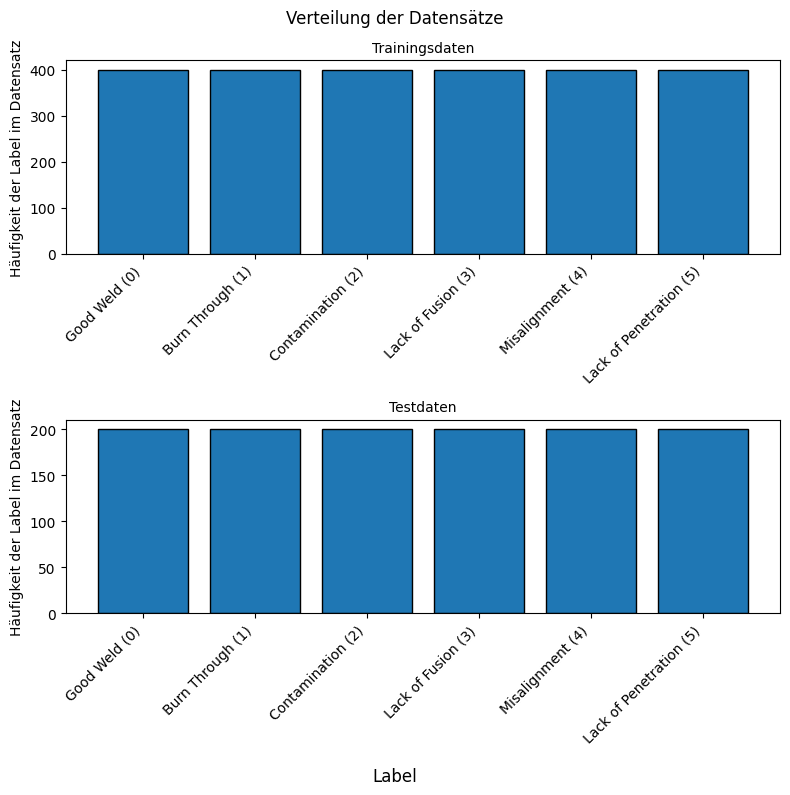

In [116]:
trunc_set.plot_distribution()

### 3. Datenaufbereitung

Die Datenaufbereitung transformiert die Rohbilder in ein numerisches Format, das für das Machine-Learning-Modell interpretierbar ist. Das beinhaltet die Bildvorverarbeitung, die Feature-Extraktion und Feature-Transformation.

#### 3.1 Bildvorverarbeitung & Skalierung



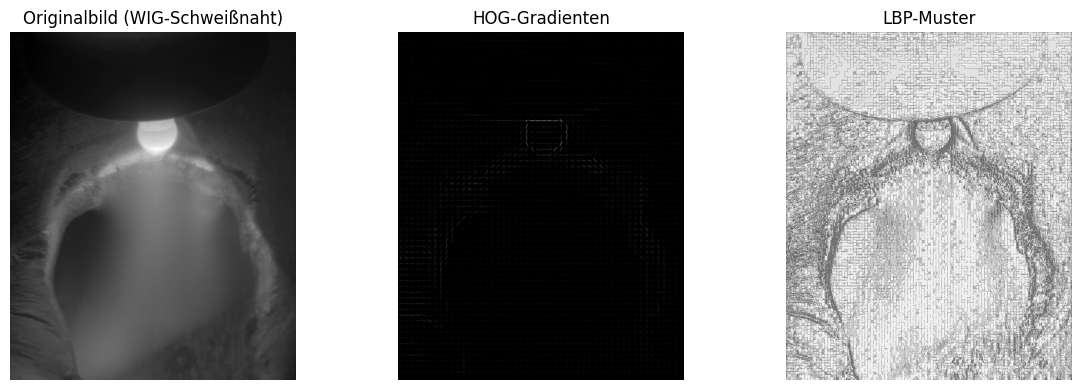

In [117]:
sample_rel_path = list(orig_set.train_data.keys())[0]
sample_path = str(orig_set.train_dir / sample_rel_path)
img = np.array(Image.open(sample_path))

_, hog_image = hog(image = img, pixels_per_cell = (16, 16), cells_per_block = (2, 2), visualize = True)

lbp_image = local_binary_pattern(image = img, P = 8, R = 1, method = 'uniform')

fig, axes = plt.subplots(1, 3, figsize = (12, 4))
axes[0].imshow(img, cmap='gray')#
axes[0].set_title("Originalbild (WIG-Schweißnaht)")
axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title("HOG-Gradienten")
axes[2].imshow(lbp_image, cmap='gray')
axes[2].set_title("LBP-Muster")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [118]:
''' Funktionierendes Modell '''

def load_hog_lbp_dataset(dataset_dict, base_dir, pixels_per_cell=(8, 8)):
    y = []
    X = []
    
    radius = 3 # Radius für die zu betrachtenden Punkte um den Zentralpunkt
    n_points = 8 * radius # n_points bestimmt die Zahl der Punkte auf der Kreislinie um den Zentralpunkt
    n_bins = n_points + 2 # Angabe über die Zahl der verschiedenen Klassen, die ein Modell zu beruecksichtigen hat. Es gibt im Nachgang eine Zahl von Merkmalen wider, die signifikant für ein Label steht.

    for image_name, label in dataset_dict.items():
        image_path = base_dir / image_name # Bildpfad für den jeweiligen Ursprungsordner, der fur die verschiedenen Aufloesungen variiert
        with Image.open(image_path) as img:
            img_array = np.array(img)

            # Histogram of Oriented Gradients (HOG)
            # orientation gibt die Zahl der beruecksichtigten Richtungswinkel an; 
            # pixel_per_cell entspricht dem Raster aus Pixeln, deren Richtungen in einem Richtungs-Histogramm aufgezeichnet werden. Werte der Richtungspfeile werden akkumuliert und in bins gespeichert, die dann als in Summe die Gesamtrichtung und Intensität der Zelle darstellen (heller oder dunkler Stern); 
            # cells_per_block normiert die relative Helligkeit eines Richtungspfeils mit der Gesamtleuchtkraft eines Block. Der beruecksichtigte Block besteht aus hier 2x2 Zellen. 
            # block_norm gibt die Art und Weise der Normierung des Blockwertes an. 
            # transform_sqrt soll die Helligkeit im Bild bei überhellen Punkten stauchen und die dunklen Bereiche aufhellen, BEVOR der HOG Algorithmus die Bereiche analysiert
            hog_features = hog(img_array, orientations = 9, pixels_per_cell= pixels_per_cell, cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True, visualize=False)

            # Local Binary Pattern (LBP)
            # local_binary_pattern gibt ein array mit features zurück, das die Anzahl in einem Bild widergibt
            lbp = local_binary_pattern(image=img_array, P = n_points, R = radius, method='uniform')
            # Das Histogramm zählt die Ergebnisse der aufgetretenen Klassen, die mittels dem Parameter 'density' in Dezimalzahlen umgewandelt werden und zusammen in Summe 1 ergeben
            lpb_hist, _ = np.histogram(lbp.ravel(), bins = n_bins, range = (0, n_bins), density = True)

            # Gewonnene Features aus dem HOG und LBP werden zusammen in einem gemeinsamen Feature-Vektor gebündelt
            combined_features = np.hstack([hog_features, lpb_hist])
            # X erhält zum ende 2400 anteile für bspw. den Trainingsdatensatz
            X.append(combined_features)
            y.append(label)
    return np.array(X), np.array(y) 
 

### 4. Modellbildung



In [ ]:
# Hilfsfunktion für das Training und die Evaluation (2, 4 oder 6 Klassen)
def train_and_evaluate_model(X_train, y_train, X_test, y_test, num_classes, subset_train, subset_test, resolution, method_name):
    print(f"\n   --- Training gestartet ({method_name.upper()}, {num_classes} Klassen) ---")
    
    # Setzen der Labels (Binär: 0 = Gut, 1 = Defekt)
    if num_classes == 2:
        y_train_mapped = np.where(y_train > 0, 1, 0)
        y_test_mapped = np.where(y_test > 0, 1, 0)
        display_labels = ["Good Weld", "Defective"]
    elif num_classes == 4:
    # Übersetzung schlechter Klassenzuweisungen zu gemischten Klassen, deren Profil ähnlich zueinander ist bzw. deren Ergebnisse überlagerten in der Confusion Matrix
        mapping = np.array([0, 1, 1, 2, 3, 2])
        y_train_mapped = mapping[y_train]
        y_test_mapped = mapping[y_test]
        display_labels = ["Good Weld", "B.T. & Cont.", "LoF & LoPe", "Misalignment"]
    else: 
        y_train_mapped = y_train
        y_test_mapped = y_test
        display_labels = lab_meaning
    
    min_orig_train = np.min(np.unique(y_train, return_counts=True)[1]) 
    min_orig_test = np.min(np.unique(y_test, return_counts=True)[1])   

    train_idx = []
    test_idx = []

    if num_classes == 2:
        # Klasse 0 (Good Weld) - Alle Daten des Datensatzes werden für das Training verwendet

        # Rückgabe eines Array aus True und False Werten und Umwandlung in Inidzes der Klasse 0
        y_train_label_gw_idx = np.where(y_train == 0)[0]
        y_test_label_gw_idx = np.where(y_test == 0)[0]
        # Entnahme der selektierten Positionen der Klasse Good Weld
        selection_train_gw = np.random.choice(y_train_label_gw_idx, size=min_orig_train, replace=False)
        selection_test_gw = np.random.choice(y_test_label_gw_idx, size=min_orig_test, replace=False)
        # 
        train_idx.extend(selection_train_gw)
        test_idx.extend(selection_test_gw)
        # Reduktion auf 1/5 der Größe aller Klassen außer der 'Good Welds', um die gleiche Menge an Elementen pro Klasse beizubehalten
        # Schlechteres Training der Einzelklassen 
        size_train_sub = min_orig_train // 5
        size_test_sub = min_orig_test // 5
        for orig_cls in [1, 2, 3, 4, 5]:
            
            y_train_label_def_idx = np.where(y_train == orig_cls)[0]
            y_test_label_def_idx = np.where(y_test == orig_cls)[0]

            selection_train_def = np.random.choice(y_train_label_def_idx, size=size_train_sub, replace=False)
            selection_test_def = np.random.choice(y_test_label_def_idx, size=size_test_sub, replace=False)

            train_idx.extend(selection_train_def)
            test_idx.extend(selection_test_def)
            
    elif num_classes == 4:
        # Klasse 0 (Good Weld): komplett
        # Rückgabe eines Array aus True und False Werten und Umwandlung in Inidzes der Klasse 0
        y_train_lable_gw_idx = np.where(y_train == 0)[0]
        y_test_lable_gw_idx = np.where(y_test == 0)[0]
        # Entnahme der selektierten Positionen der Klasse Good Weld
        selection_train_gw = np.random.choice(y_train_lable_gw_idx, size=min_orig_train, replace=False)
        selection_test_gw = np.random.choice(y_test_lable_gw_idx, size=min_orig_test, replace=False)
        # Erweiterung der Liste der Indizes
        train_idx.extend(selection_train_gw)
        test_idx.extend(selection_test_gw)
        
        # Klasse 1 (Burn & Contam): Reduktion um 1/2 der Größe aus Klasse 1 und Klasse 2, um die gleiche Menge an Elementen pro Klasse beizubehalten
        size_train_sub = min_orig_train // 2
        size_test_sub = min_orig_test // 2
        for orig_cls in [1, 2]:
            train_idx.extend(np.random.choice(np.where(y_train == orig_cls)[0], size=size_train_sub, replace=False))
            test_idx.extend(np.random.choice(np.where(y_test == orig_cls)[0], size=size_test_sub, replace=False))
            
        # Klasse 2 (Fusion & Penet): Reduktion um 1/2 der Größe aus Klasse 3 und Klasse 5, um die gleiche Menge an Elementen pro Klasse beizubehalten
        for orig_cls in [3, 5]:
            train_idx.extend(np.random.choice(np.where(y_train == orig_cls)[0], size=size_train_sub, replace=False))
            test_idx.extend(np.random.choice(np.where(y_test == orig_cls)[0], size=size_test_sub, replace=False))
            
        # Klasse 3 (Misalignment): komplett aus Klasse 4
        # Misalignment wird als separater Fall behandelt, da bei vorherigen Durchläufen wenig Überschneidung mit anderen Klassen vorlag
        train_idx.extend(np.random.choice(np.where(y_train == 4)[0], size=min_orig_train, replace=False))
        test_idx.extend(np.random.choice(np.where(y_test == 4)[0], size=min_orig_test, replace=False))
        
    else: # 6 Klassen (kein Downsampling nötig)
        train_idx = list(range(len(y_train)))
        test_idx = list(range(len(y_test)))

    # Ausgewählte Indizes auf die Daten anwenden
    X_train_bal = X_train[train_idx]
    y_train_bal = y_train_mapped[train_idx]
    X_test_bal = X_test[test_idx]
    y_test_bal = y_test_mapped[test_idx]
    

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()), 
        ("svm", SVC(kernel="rbf", class_weight='balanced'))
        ])
    

    # C ist die Einstellung der Margin als "soft" oder "hard"
    # Einstellparameter für SVM
    param_grid = {
        "svm__C": [0.1, 0.5, 1, 2],
        "svm__gamma": ["scale", "auto"]
    }
    # Nur die übergeordneten Ordnernamen werden in "train_groups" übernommen
    train_groups = [Path(rel_path).parts[0] for rel_path in subset_train.keys()]
    train_groups_bal = [train_groups[i] for i in train_idx]

    cv_groups = GroupKFold(n_splits=5)
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv_groups,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train_bal, y_train_bal, groups=train_groups_bal)
    
    print(f"    Beste Parameter: {grid.best_params_}")
    print(f"    Bester CV-Score: {grid.best_score_:.4f}")
    
    y_pred = grid.predict(X_test_bal)
    test_accuracy = accuracy_score(y_test_bal, y_pred)
    print(f"    Genauigkeit auf Testset: {test_accuracy:.2%}\n")
    print(classification_report(y_test_bal, y_pred, target_names=display_labels))
    
    # Confusion Matrix plotten
    cm = confusion_matrix(y_test_bal, y_pred)
    plt.figure(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=plt.gca())
    plt.title(f"Confusion Matrix ({method_name.upper()}, {num_classes} Klassen, {resolution[0]}x{resolution[1]} px)")
    plt.tight_layout()
    plt.show()

      
    # --- 1. SCHRITT: Decision Scores von der SVM holen ---
    # Tipp: SVC nutzt nicht predict_proba (außer probability=True), sondern decision_function!
    y_score = grid.decision_function(X_test_bal)

    plt.figure(figsize=(7, 6))

    if num_classes == 2:
        # --- 2. SCHRITT: Binärer Fall (2 Klassen) ---
        # Tipp: roc_curve braucht (wahre_labels, decision_scores)
        fpr, tpr, _ = roc_curve(y_true = y_test_bal, y_score = y_score)# TODO: Rufe roc_curve auf
        roc_auc = auc(fpr, tpr) # TODO: Berechne auc(fpr, tpr)
        
        # TODO: Plotte die Kurve mit plt.plot(fpr, tpr, ...) und zeige auc im Label an
        print(f"    ROC-AUC Score: {roc_auc:.4f}")
        plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC Kurve (AUC = {roc_auc:.4f})')
        print(f"    ROC-AUC Score: {roc_auc:.4f}")       
    else:
        # --- 3. SCHRITT: Multi-Class Fall (4 & 6 Klassen, One-vs-Rest) ---
        # Tipp: label_binarize wandelt z.B. Label 2 in [0, 0, 1, 0] um.
        y_test_bin = label_binarize(y = y_test_bal, classes = list(range(num_classes))) # TODO: Nutze label_binarize(y_test_bal, classes=list(range(num_classes)))
        
        auc_list = []
        for i in range(num_classes):
            # Tipp: Greife auf die i-te Spalte zu: y_test_bin[:, i] und y_score[:, i]
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])# TODO: roc_curve für Klasse i berechnen
            roc_auc = auc(fpr, tpr) # TODO: auc(fpr, tpr) berechnen
            auc_list.append(roc_auc)

            plt.plot(fpr, tpr, lw=1.5, label=f'{display_labels[i]} (AUC = {roc_auc:.2f})')
            
            # TODO: Plotte die Kurve für Klasse i mit dem Namen display_labels[i]
            
        macro_auc = np.mean(auc_list) # TODO: Berechne den Mittelwert (np.mean) aus auc_list
        print(f"    Macro-Average ROC-AUC Score: {macro_auc:.4f}")

    # --- 4. SCHRITT: Diagramm-Styling & Achsen ---
    plt.plot([0,1], [0,1], color='black', linestyle='--', lw=1, label='Zufall (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Falsch-Positiv-Rate)')
    plt.ylabel('True Positive Rate (Richtig-Positiv-Rate)')
    plt.title(f'ROC-Kurve OvR ({method_name.upper()}, {num_classes} Klassen, {resolution[0]}x{resolution[1]} px)')
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    wrong_idx = np.where(y_pred != y_test_bal)[0]
    errors_captured = []

    for idx in wrong_idx[:2]:
        rel_path = list(subset_test.keys())[test_idx[idx]]
        full_img_path = str(Path(f"./subset_{resolution[0]}x{resolution[1]}_{method_name}") / "test" / rel_path)
        errors_captured.append({'path': list(subset_test.keys())[test_idx[idx]], 'true_label': display_labels[y_test_bal[idx]], 'pred_label': display_labels[y_pred[idx]], 'method': method_name, 'classes': num_classes})
    
    return test_accuracy, grid.best_score_, errors_captured


In [120]:
def analyze_pca_variance(X, variance_threshold=0.8):
    # Features standardisieren
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA fitten
    pca = PCA()
    pca.fit(X_scaled)
    
    # Kumulative erklärte Varianz berechnen
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    
    # Finden, wie viele Komponenten benötigt werden
    n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    variance_covered = cumulative_variance[n_components - 1] * 100
    
    print(f"=== PCA Varianz Analyse ===")
    print(f"Gesamtanzahl ursprünglicher Features: {X.shape[1]}")
    print(f"Benötigte Komponenten für >= {variance_threshold*100}% Varianz: {n_components}")
    print(f"Tatsächlich abgedeckte Varianz mit {n_components} Komponenten: {variance_covered:.2f}%")
    
    # Plot erstellen
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', markersize=2)
    plt.axhline(y=variance_threshold, color='r', linestyle='--', label=f'{variance_threshold*100}% Varianz')
    plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} Komponenten')
    plt.xlabel('Anzahl der Hauptkomponenten')
    plt.ylabel('Kumulative erklärte Varianz')
    plt.title('Kumulative erklärte Varianz vs. Anzahl der Komponenten')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return n_components, cumulative_variance



In [121]:
def load_fft_dataset(dataset_dict, base_dir, crop_size=32):
    X = []
    y = []
    for image_name, label in dataset_dict.items():
        image_path = base_dir / image_name
        with Image.open(image_path) as img: 
            img_array = np.array(img)
            # 2D Fast Fourier Transform
            f_transform = np.fft.fft2(img_array)
            # Shift der niedrigen Frequenzen in die Mitte
            f_shift = np.fft.fftshift(f_transform)
            # Magnitude der Frequenzen berechnen, da keine Rücktransformation als Bild notwendig ist (hohe und niedrige Frequenzen unterscheiden -- grobe und feine Strukturen)
            magnitude_spectrum = np.log(np.abs(f_shift) + 1)
            # Mitte des Spektrums bestimmen, um einen Filter darüber zu legen, der die hohen Frequenzen entfernt und die niedrigen beibehält

            rows, cols = magnitude_spectrum.shape
            crow, ccol = rows // 2, cols // 2
            half_crop = crop_size // 2

            # Bildbereich mit der angeforderten Zahl an niedrigen Frequenzfeatures entnehmen
            crop = magnitude_spectrum[  crow - half_crop : crow + half_crop, 
                                        ccol - half_crop : ccol + half_crop]
            
            X.append(crop.flatten())
            y.append(label)
    return np.array(X), np.array(y)

In [122]:

def conduct_experiments(experiment_oi, sample_size_test, sample_size_train, PCA_option = False):

    results = {}

    for exp in experiment_oi:
        res = exp["resolution"]
        res_key = f"{res[0]}x{res[1]}"
        results[res_key] = {}
        
        # 1. Methode und Parameter dynamisch ermitteln
        if "pixels_per_cell" in exp:
            process_name = "HOG + LBP"
            process = "hog_lbp_pca" if PCA_option else "hog_lbp"
            cell_size = exp["pixels_per_cell"]
        elif "crop_size" in exp:
            process_name = "2D-FFT"
            process = "fft"
            crop_sz = exp["crop_size"]
        print(f"=== Prozess-Start von {process_name}: {res_key} ===")
        

        #output_dir = Path(f"/kaggle/working/subset_{res_key}_hog_lbp")
        output_dir = Path(f"./subset_{res_key}_{process}")
        subset_train, _ = orig_set.create_balanced_subset(output_dir, "train", samples_per_label=sample_size_train, target_size=res, copy_files=True)
        subset_test, _ = orig_set.create_balanced_subset(output_dir, "test", samples_per_label=sample_size_test, target_size=res, copy_files=True)
        
        print(f"Extrahiere Features ({process_name})...")
        
        # 3. Passende Feature-Extraktion aufrufen
        if "pixels_per_cell" in exp:
            X_train, y_train = load_hog_lbp_dataset(subset_train, output_dir / "train", cell_size)
            X_test, y_test = load_hog_lbp_dataset(subset_test, output_dir / "test", cell_size)
        else: # fft
            X_train, y_train = load_fft_dataset(subset_train, output_dir / "train", crop_size=crop_sz)
            X_test, y_test = load_fft_dataset(subset_test, output_dir / "test", crop_size=crop_sz)
        
        if PCA_option: 
            n_comp, _ = analyze_pca_variance(X_train, variance_threshold=0.8)

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            pca = PCA(n_components=n_comp, random_state=42)
            X_train = pca.fit_transform(X_train_scaled)
            X_test = pca.transform(X_test_scaled)
              
        print(f'Menge der generierten Features: X_train {X_train.shape}, y_train {y_train.shape}')

        # Lauf für 2, 4 und 6 Klassen ausführen
        for num_cls in [2, 4, 6]:
            test_acc, cv_score, errors_cap = train_and_evaluate_model(
                X_train, y_train, X_test, y_test, 
                num_classes=num_cls, 
                subset_train=subset_train, 
                resolution=res,
                method_name=process, 
                subset_test = subset_test
            )
            results[res_key][f"{num_cls}_classes"] = {"test_acc": test_acc, "cv_score": cv_score, "errors": errors_cap}
    # 5. Zusammenfassung ausgeben
    print(f"\n=== ZUSAMMENFASSUNG EXPERIMENT ===")
    for res_key, classes_dict in results.items():
        print(f"\nAuflösung: {res_key}")
        for cls_key, metrics in classes_dict.items():
            print(f"  -> {cls_key:10s} | CV-Score (F1): {metrics['cv_score']:.4f} | Test-Genauigkeit: {metrics['test_acc']:.2%}")
  
            
    return results


=== Prozess-Start von HOG + LBP: 128x128 ===
Bilder kopiert & verkleinert auf (128, 128): 2400 nach: subset_128x128_hog_lbp/train
Subset-JSON gespeichert: subset_128x128_hog_lbp/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (128, 128): 600 nach: subset_128x128_hog_lbp/test
Subset-JSON gespeichert: subset_128x128_hog_lbp/test/test.json
Gesamtzahl im Subset: 600


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,100
1,1,200,100
2,2,200,100
3,3,200,100
4,4,200,100
5,5,200,100


Extrahiere Features (HOG + LBP)...
Menge der generierten Features: X_train (2400, 8126), y_train (2400,)

   --- Training gestartet (HOG_LBP, 2 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.7058
    Genauigkeit auf Testset: 79.00%

              precision    recall  f1-score   support

   Good Weld       0.74      0.89      0.81       100
   Defective       0.86      0.69      0.77       100

    accuracy                           0.79       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



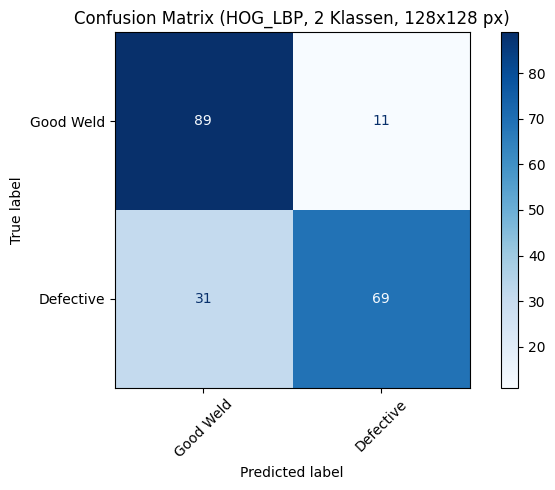

    ROC-AUC Score: 0.9122
    ROC-AUC Score: 0.9122


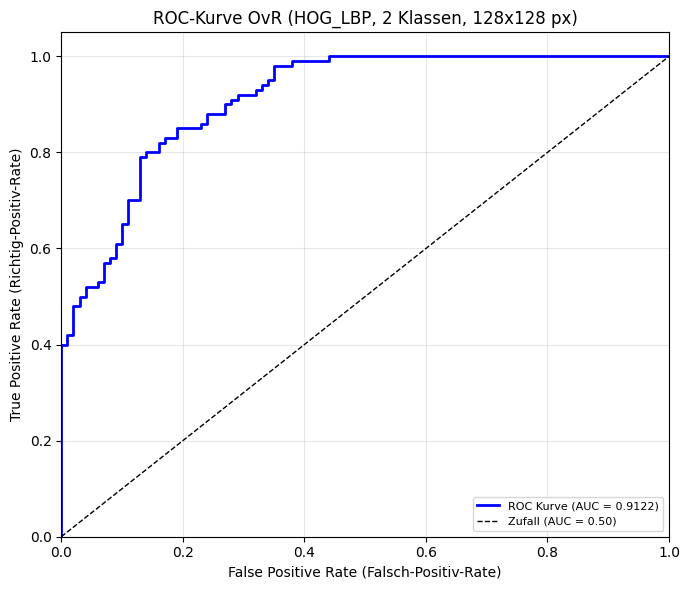


   --- Training gestartet (HOG_LBP, 4 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.3556
    Genauigkeit auf Testset: 62.25%

              precision    recall  f1-score   support

   Good Weld       0.92      0.84      0.88       100
B.T. & Cont.       0.83      0.73      0.78       100
  LoF & LoPe       0.46      0.50      0.48       100
Misalignment       0.37      0.42      0.39       100

    accuracy                           0.62       400
   macro avg       0.65      0.62      0.63       400
weighted avg       0.65      0.62      0.63       400



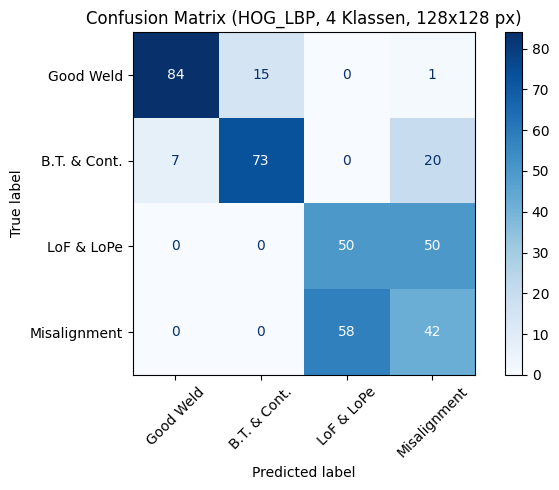

    Macro-Average ROC-AUC Score: 0.8184


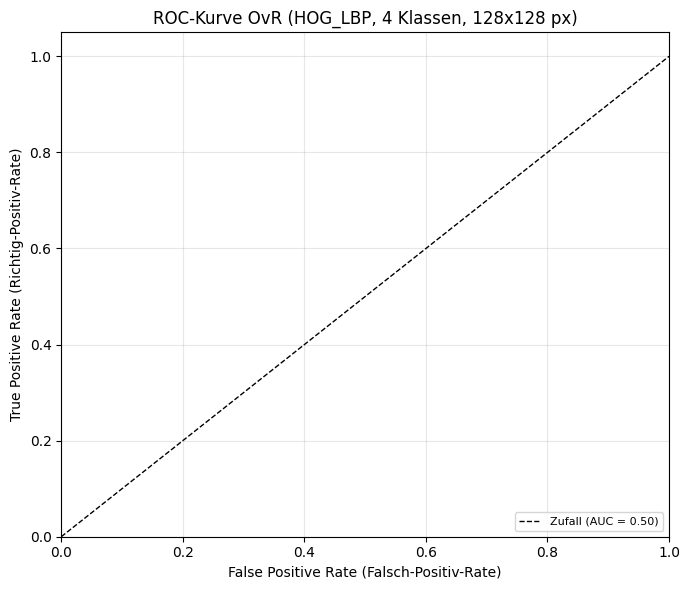


   --- Training gestartet (HOG_LBP, 6 Klassen) ---
    Beste Parameter: {'svm__C': 2, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.2549
    Genauigkeit auf Testset: 48.00%

                     precision    recall  f1-score   support

          Good Weld       0.53      0.78      0.63       100
       Burn Through       0.55      0.85      0.67       100
      Contamination       0.00      0.00      0.00       100
     Lack of Fusion       0.57      0.54      0.56       100
       Misalignment       0.08      0.06      0.07       100
Lack of Penetration       0.52      0.65      0.58       100

           accuracy                           0.48       600
          macro avg       0.38      0.48      0.42       600
       weighted avg       0.38      0.48      0.42       600



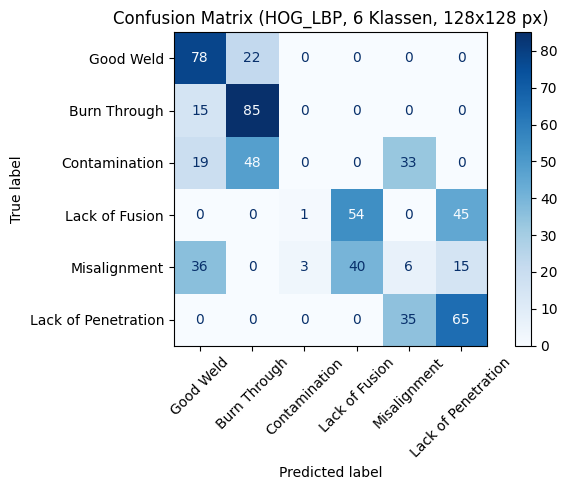

    Macro-Average ROC-AUC Score: 0.8214


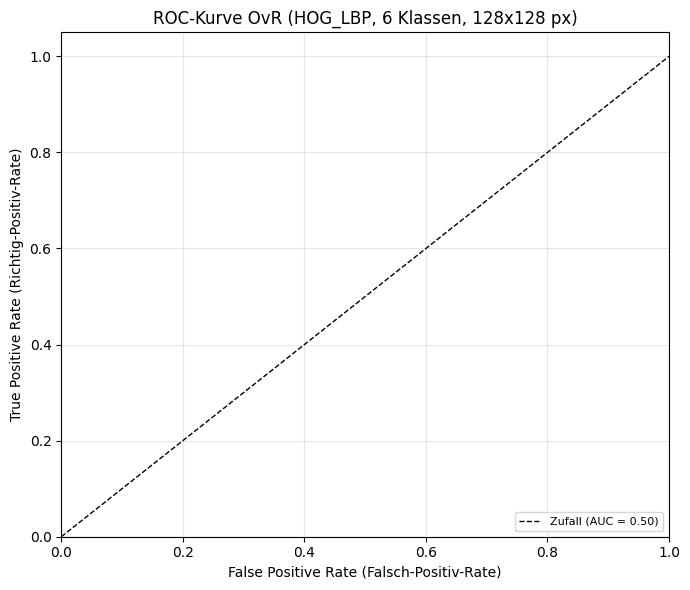

=== Prozess-Start von HOG + LBP: 256x256 ===
Bilder kopiert & verkleinert auf (256, 256): 2400 nach: subset_256x256_hog_lbp/train
Subset-JSON gespeichert: subset_256x256_hog_lbp/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (256, 256): 600 nach: subset_256x256_hog_lbp/test
Subset-JSON gespeichert: subset_256x256_hog_lbp/test/test.json
Gesamtzahl im Subset: 600


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,100
1,1,200,100
2,2,200,100
3,3,200,100
4,4,200,100
5,5,200,100


Extrahiere Features (HOG + LBP)...
Menge der generierten Features: X_train (2400, 8126), y_train (2400,)

   --- Training gestartet (HOG_LBP, 2 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.6958
    Genauigkeit auf Testset: 70.50%

              precision    recall  f1-score   support

   Good Weld       0.68      0.79      0.73       100
   Defective       0.75      0.62      0.68       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



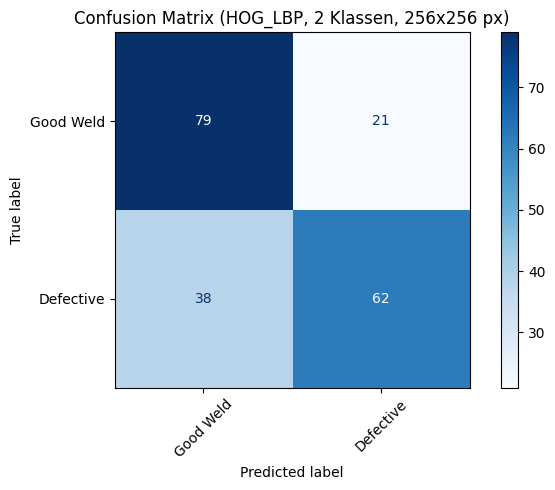

    ROC-AUC Score: 0.8563
    ROC-AUC Score: 0.8563


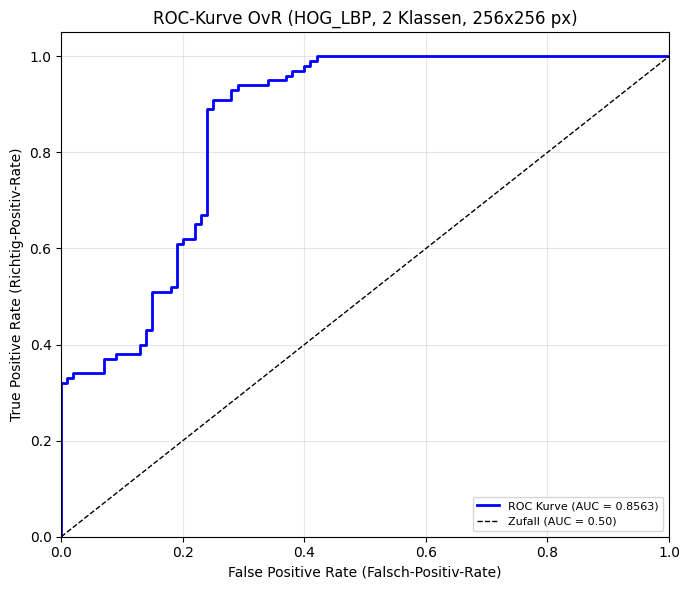


   --- Training gestartet (HOG_LBP, 4 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.3074
    Genauigkeit auf Testset: 56.50%

              precision    recall  f1-score   support

   Good Weld       0.76      0.74      0.75       100
B.T. & Cont.       0.86      0.69      0.77       100
  LoF & LoPe       0.42      0.50      0.46       100
Misalignment       0.31      0.33      0.32       100

    accuracy                           0.56       400
   macro avg       0.59      0.56      0.57       400
weighted avg       0.59      0.56      0.57       400



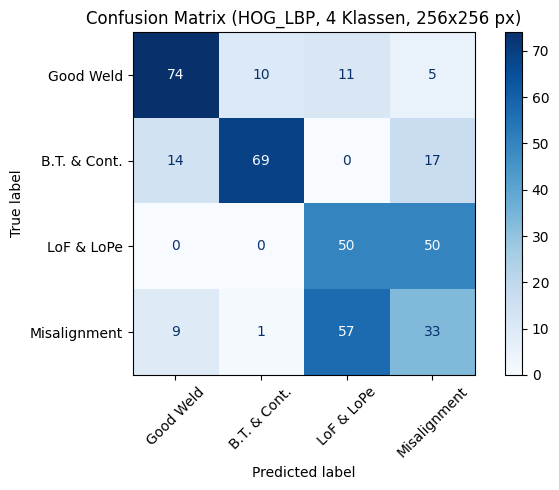

    Macro-Average ROC-AUC Score: 0.7693


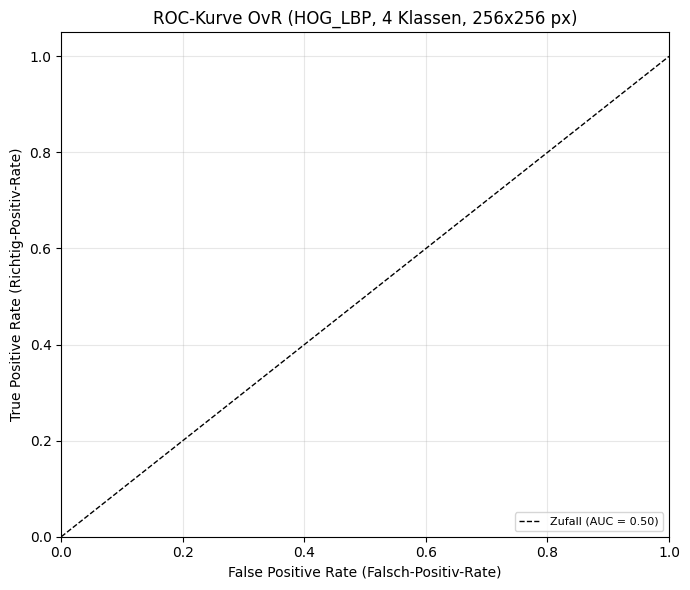


   --- Training gestartet (HOG_LBP, 6 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.2660
    Genauigkeit auf Testset: 40.67%

                     precision    recall  f1-score   support

          Good Weld       0.55      0.83      0.66       100
       Burn Through       0.60      0.69      0.64       100
      Contamination       0.00      0.00      0.00       100
     Lack of Fusion       0.72      0.57      0.64       100
       Misalignment       0.20      0.35      0.26       100
Lack of Penetration       0.00      0.00      0.00       100

           accuracy                           0.41       600
          macro avg       0.35      0.41      0.37       600
       weighted avg       0.35      0.41      0.37       600



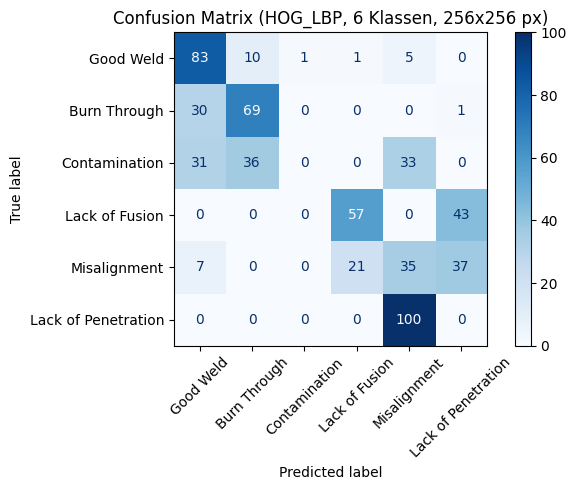

    Macro-Average ROC-AUC Score: 0.7939


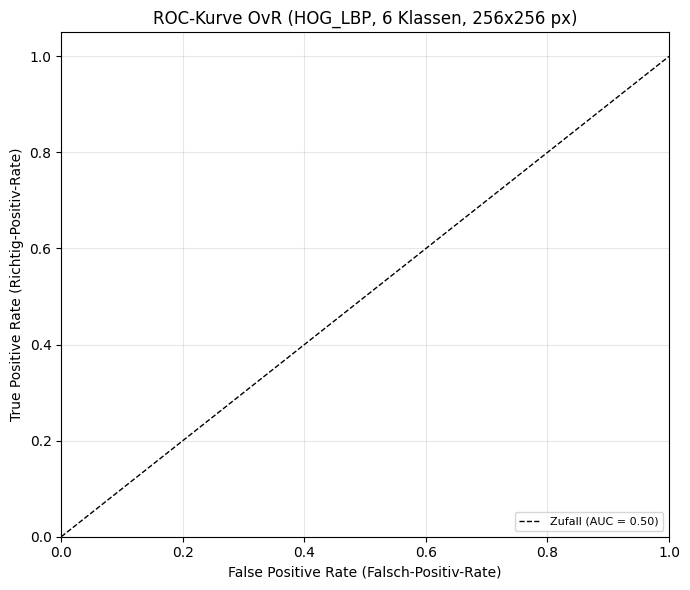


=== ZUSAMMENFASSUNG EXPERIMENT ===

Auflösung: 128x128
  -> 2_classes  | CV-Score (F1): 0.7058 | Test-Genauigkeit: 79.00%
  -> 4_classes  | CV-Score (F1): 0.3556 | Test-Genauigkeit: 62.25%
  -> 6_classes  | CV-Score (F1): 0.2549 | Test-Genauigkeit: 48.00%

Auflösung: 256x256
  -> 2_classes  | CV-Score (F1): 0.6958 | Test-Genauigkeit: 70.50%
  -> 4_classes  | CV-Score (F1): 0.3074 | Test-Genauigkeit: 56.50%
  -> 6_classes  | CV-Score (F1): 0.2660 | Test-Genauigkeit: 40.67%


In [128]:
# Auflösungs-Experimente für HOG + LBP 
experiments_hog = [
    {"resolution": (128, 128), "pixels_per_cell": (8, 8)},
    {"resolution": (256, 256), "pixels_per_cell": (16, 16)}
]
results_hog = {}
results_hog = conduct_experiments(experiments_hog, sample_size_train=400, sample_size_test=100)

=== Prozess-Start von 2D-FFT: 128x128 ===
Bilder kopiert & verkleinert auf (128, 128): 2400 nach: subset_128x128_fft/train
Subset-JSON gespeichert: subset_128x128_fft/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (128, 128): 1200 nach: subset_128x128_fft/test
Subset-JSON gespeichert: subset_128x128_fft/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


Extrahiere Features (2D-FFT)...
Menge der generierten Features: X_train (2400, 1024), y_train (2400,)

   --- Training gestartet (FFT, 2 Klassen) ---
    Beste Parameter: {'svm__C': 0.5, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.5675
    Genauigkeit auf Testset: 87.00%

              precision    recall  f1-score   support

   Good Weld       0.80      0.98      0.88       200
   Defective       0.98      0.76      0.85       200

    accuracy                           0.87       400
   macro avg       0.89      0.87      0.87       400
weighted avg       0.89      0.87      0.87       400



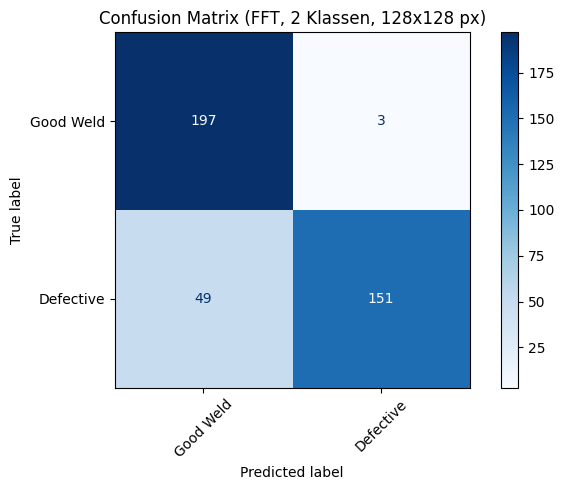

    ROC-AUC Score: 0.9628
    ROC-AUC Score: 0.9628


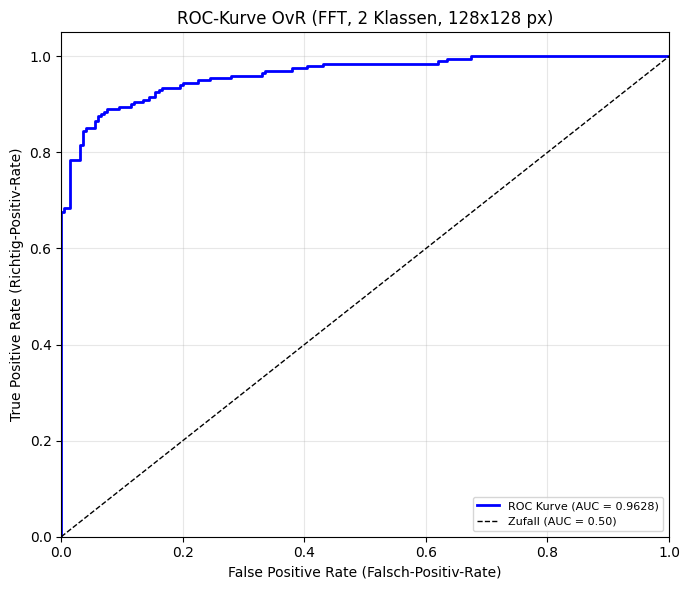


   --- Training gestartet (FFT, 4 Klassen) ---
    Beste Parameter: {'svm__C': 0.1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.3632
    Genauigkeit auf Testset: 63.75%

              precision    recall  f1-score   support

   Good Weld       0.75      0.94      0.83       200
B.T. & Cont.       0.85      0.81      0.83       200
  LoF & LoPe       0.52      0.38      0.44       200
Misalignment       0.40      0.41      0.40       200

    accuracy                           0.64       800
   macro avg       0.63      0.64      0.63       800
weighted avg       0.63      0.64      0.63       800



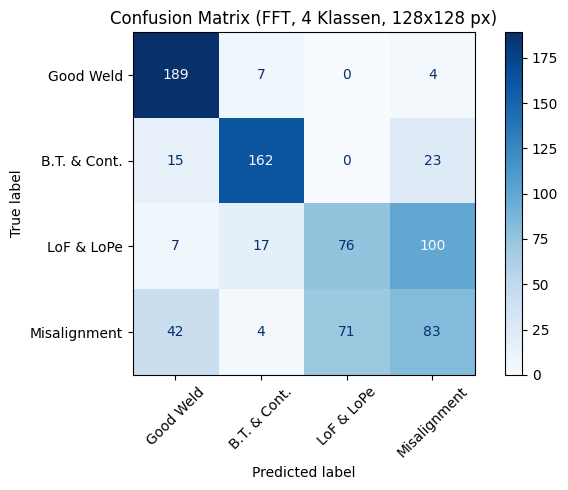

    Macro-Average ROC-AUC Score: 0.7408


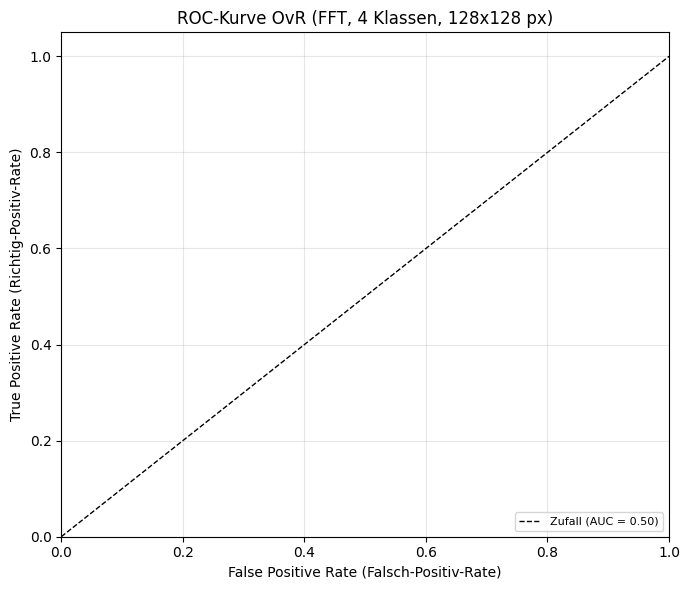


   --- Training gestartet (FFT, 6 Klassen) ---
    Beste Parameter: {'svm__C': 2, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.2757
    Genauigkeit auf Testset: 48.75%

                     precision    recall  f1-score   support

          Good Weld       0.59      0.80      0.68       200
       Burn Through       0.64      0.89      0.74       200
      Contamination       0.29      0.07      0.12       200
     Lack of Fusion       0.66      0.74      0.70       200
       Misalignment       0.23      0.43      0.30       200
Lack of Penetration       0.00      0.00      0.00       200

           accuracy                           0.49      1200
          macro avg       0.40      0.49      0.42      1200
       weighted avg       0.40      0.49      0.42      1200



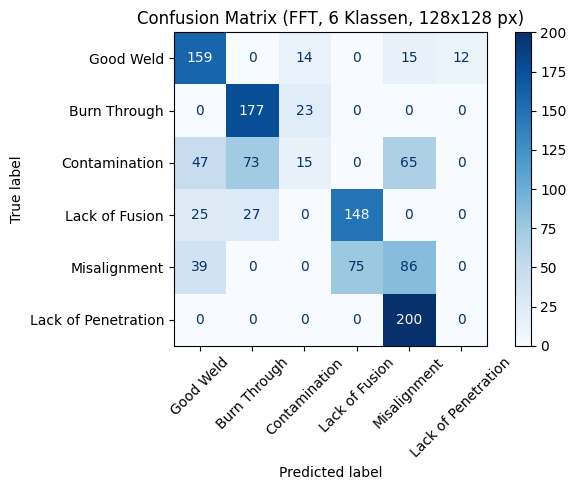

    Macro-Average ROC-AUC Score: 0.8232


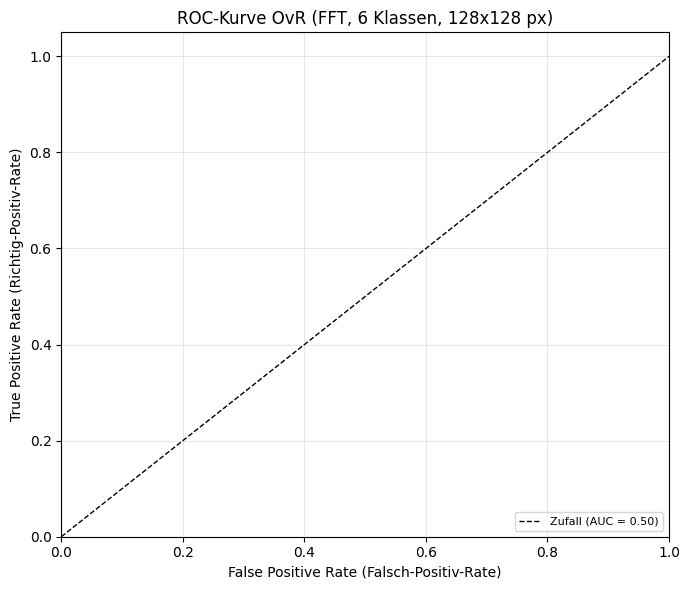

=== Prozess-Start von 2D-FFT: 256x256 ===
Bilder kopiert & verkleinert auf (256, 256): 2400 nach: subset_256x256_fft/train
Subset-JSON gespeichert: subset_256x256_fft/train/train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,400,400
1,1,400,400
2,2,400,400
3,3,400,400
4,4,400,400
5,5,400,400


Bilder kopiert & verkleinert auf (256, 256): 1200 nach: subset_256x256_fft/test
Subset-JSON gespeichert: subset_256x256_fft/test/test.json
Gesamtzahl im Subset: 1200


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,200,200
1,1,200,200
2,2,200,200
3,3,200,200
4,4,200,200
5,5,200,200


Extrahiere Features (2D-FFT)...
Menge der generierten Features: X_train (2400, 4096), y_train (2400,)

   --- Training gestartet (FFT, 2 Klassen) ---
    Beste Parameter: {'svm__C': 0.1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.7197
    Genauigkeit auf Testset: 89.75%

              precision    recall  f1-score   support

   Good Weld       0.83      0.99      0.91       200
   Defective       0.99      0.80      0.89       200

    accuracy                           0.90       400
   macro avg       0.91      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400



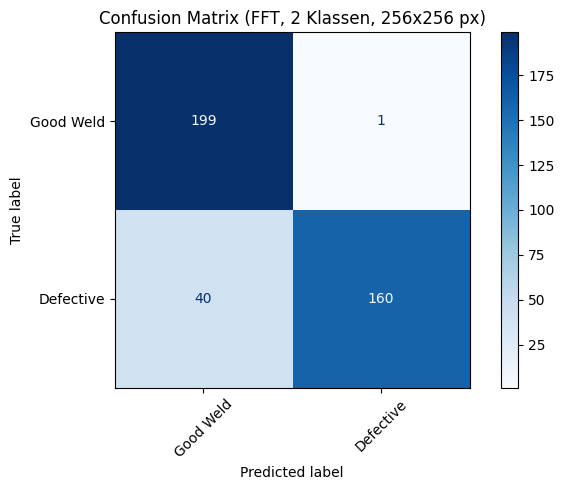

    ROC-AUC Score: 0.9787
    ROC-AUC Score: 0.9787


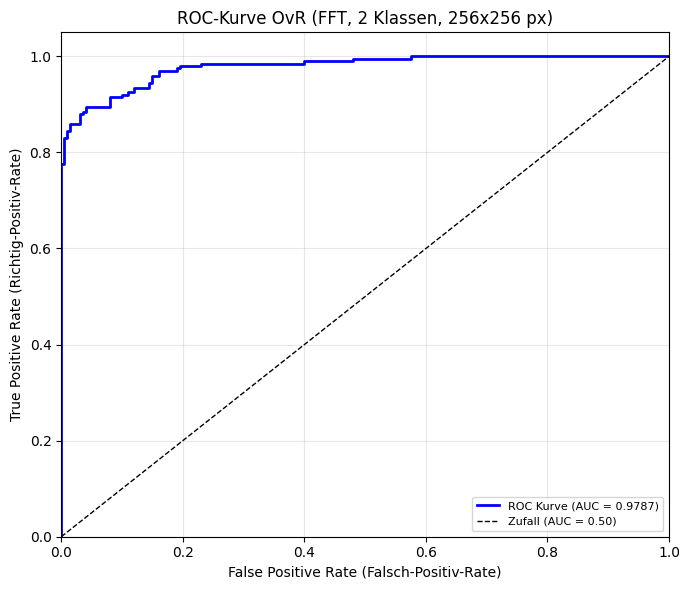


   --- Training gestartet (FFT, 4 Klassen) ---
    Beste Parameter: {'svm__C': 1, 'svm__gamma': 'scale'}
    Bester CV-Score: 0.4423
    Genauigkeit auf Testset: 56.38%

              precision    recall  f1-score   support

   Good Weld       0.75      0.74      0.75       200
B.T. & Cont.       0.90      0.84      0.87       200
  LoF & LoPe       0.36      0.43      0.40       200
Misalignment       0.27      0.23      0.25       200

    accuracy                           0.56       800
   macro avg       0.57      0.56      0.57       800
weighted avg       0.57      0.56      0.57       800



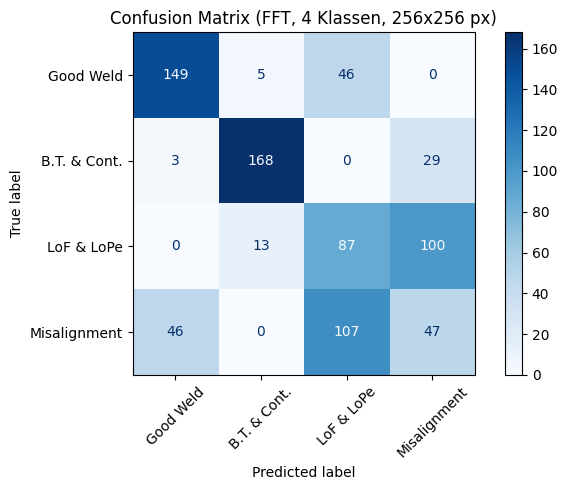

    Macro-Average ROC-AUC Score: 0.7363


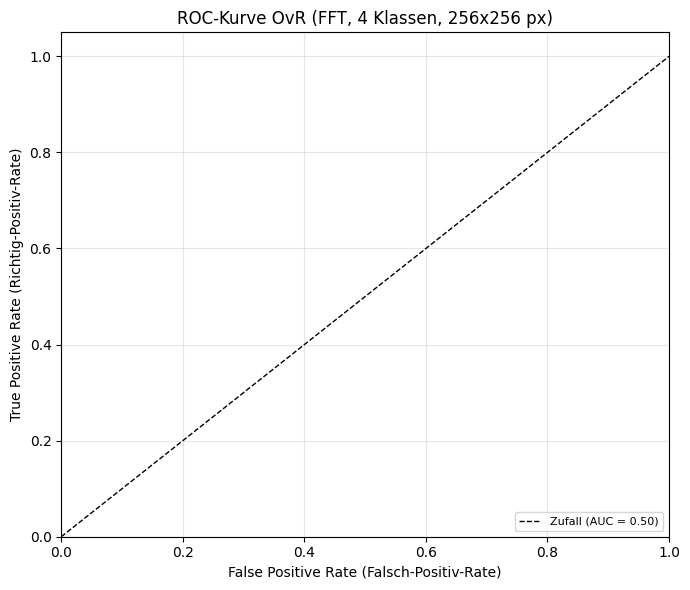


   --- Training gestartet (FFT, 6 Klassen) ---
    Beste Parameter: {'svm__C': 2, 'svm__gamma': 'auto'}
    Bester CV-Score: 0.3250
    Genauigkeit auf Testset: 43.67%

                     precision    recall  f1-score   support

          Good Weld       0.83      0.79      0.81       200
       Burn Through       0.36      0.18      0.24       200
      Contamination       0.33      0.40      0.36       200
     Lack of Fusion       0.61      0.83      0.70       200
       Misalignment       0.24      0.42      0.31       200
Lack of Penetration       0.00      0.00      0.00       200

           accuracy                           0.44      1200
          macro avg       0.39      0.44      0.40      1200
       weighted avg       0.39      0.44      0.40      1200



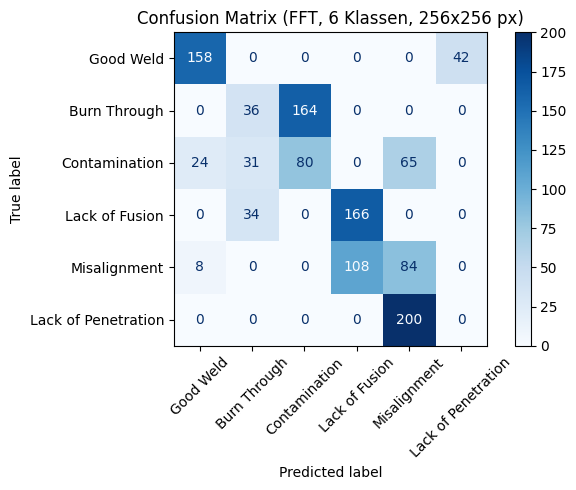

    Macro-Average ROC-AUC Score: 0.8196


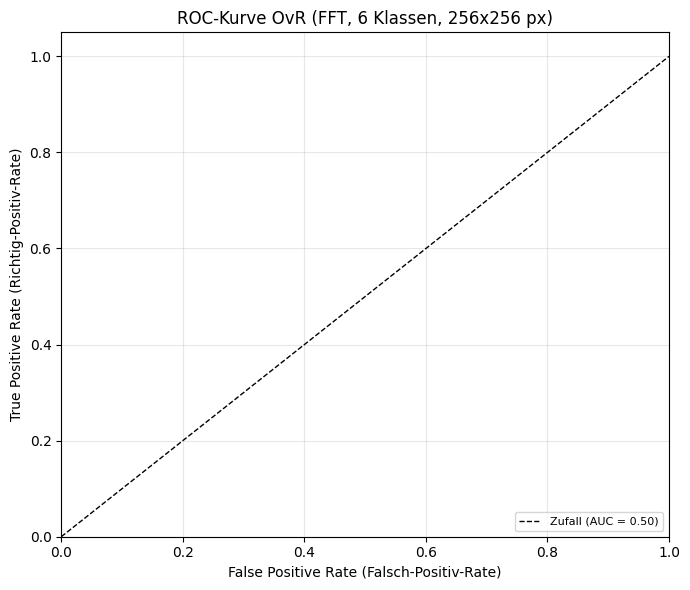


=== ZUSAMMENFASSUNG EXPERIMENT ===

Auflösung: 128x128
  -> 2_classes  | CV-Score (F1): 0.5675 | Test-Genauigkeit: 87.00%
  -> 4_classes  | CV-Score (F1): 0.3632 | Test-Genauigkeit: 63.75%
  -> 6_classes  | CV-Score (F1): 0.2757 | Test-Genauigkeit: 48.75%

Auflösung: 256x256
  -> 2_classes  | CV-Score (F1): 0.7197 | Test-Genauigkeit: 89.75%
  -> 4_classes  | CV-Score (F1): 0.4423 | Test-Genauigkeit: 56.38%
  -> 6_classes  | CV-Score (F1): 0.3250 | Test-Genauigkeit: 43.67%


In [124]:
experiments_fft = [
    {"resolution": (128, 128), "crop_size": 32},
    {"resolution": (256, 256), "crop_size": 64}
]
results_fft = {}

results_fft = conduct_experiments(experiments_fft, sample_size_train=400, sample_size_test=200)

In [125]:
# # Auflösungs-Experimente für HOG + LBP 
# experiments_hog = [
#     {"resolution": (128, 128), "pixels_per_cell": (8, 8)},
#     {"resolution": (256, 256), "pixels_per_cell": (16, 16)}
# ]
# results_hog = {}

# for exp in experiments_hog:
#     res = exp["resolution"]
#     cell_size = exp["pixels_per_cell"]
#     res_key = f"{res[0]}x{res[1]}"
#     results_hog[res_key] = {}
    
#     print(f"=== Prozess-Start von HOG + LBP: {res_key} ===")
    

#     #output_dir = Path(f"/kaggle/working/subset_{res_key}_hog_lbp")
#     output_dir = Path(f"./subset_{res_key}_hog_lbp")
#     subset_train, _ = orig_set.create_balanced_subset(output_dir, "train", samples_per_label=400, target_size=res, copy_files=True)
#     subset_test, _ = orig_set.create_balanced_subset(output_dir, "test", samples_per_label=150, target_size=res, copy_files=True)
    
#     print("Extrahiere Features (HOG + LBP)...")
#     X_train, y_train = load_hog_lbp_dataset(subset_train, output_dir / "train", cell_size)
#     X_test, y_test = load_hog_lbp_dataset(subset_test, output_dir / "test", cell_size)
    
#     print(f'\nMenge der generierten Features X_train liegt bei {X_train.shape} und y_train bein {y_train.shape}')

#     # Lauf für 2, 4 und 6 Klassen ausführen
#     for num_cls in [2, 4, 6]:
#         test_acc, cv_score = train_and_evaluate_model(
#             X_train, y_train, X_test, y_test, 
#             num_classes=num_cls, 
#             subset_train=subset_train, 
#             resolution=res,
#             method_name="hog_lbp"
#         )
#         results_hog[res_key][f"{num_cls}_classes"] = {"test_acc": test_acc, "cv_score": cv_score}

# # Zusammenfassung HOG+LBP
# print("\n=== ZUSAMMENFASSUNG HOG + LBP ===")
# for res_key, classes_dict in results_hog.items():
#     print(f"\nAuflösung: {res_key}")
#     for cls_key, metrics in classes_dict.items():
#         print(f"  -> {cls_key:10s} | CV-Score (F1): {metrics['cv_score']:.4f} | Test-Genauigkeit: {metrics['test_acc']:.2%}")



In [126]:
# # Auflösungs-Experimente für 2D-FFT (voller Datensatz)
# experiments_fft = [
#     {"resolution": (128, 128)},
#     {"resolution": (256, 256)},
    
# ]
# results_fft = {}

# for exp in experiments_fft:
#     res = exp["resolution"]
#     res_key = f"{res[0]}x{res[1]}"
#     results_fft[res_key] = {}
    

#     print(f"=== Prozess-Start von 2D-FFT: {res_key} ===")

    
#     # Pfad zur Speicherung des Datensatzes für die Fourier Transformation
#     #output_dir = Path(f"/kaggle/working/subset_{res_key}_fft")
#     output_dir = Path(f"./subset_{res_key}_fft")
#     subset_train, _ = orig_set.create_balanced_subset(output_dir, "train", samples_per_label=400, target_size=res, copy_files=True)
#     subset_test, _ = orig_set.create_balanced_subset(output_dir, "test", samples_per_label=200, target_size=res, copy_files=True)

#     # Crop Size wird an die Größe des Bildes angepasst, so dass prozentual dieselbe Menge an Frequenzinformationen extrahiert werden
#     current_crop = res[0] // 4  # Bei 128x128 -> Crop 32 | Bei 256x256 -> Crop 64
#     print(f"Extrahiere Features (2D-FFT) mit Crop-Size {current_crop}...")

#     X_train, y_train = load_fft_dataset(subset_train, output_dir / "train", crop_size=current_crop)
#     X_test, y_test = load_fft_dataset(subset_test, output_dir / "test", crop_size=current_crop)

#     # Lauf für 6 Klassen und 2 Klassen ausführen
#     for num_cls in [2, 4, 6]:
#         test_acc, cv_score = train_and_evaluate_model(
#             X_train, y_train, X_test, y_test, 
#             num_classes=num_cls, 
#             subset_train=subset_train, 
#             resolution=res,
#             method_name="fft"
#         )
#         results_fft[res_key][f"{num_cls}_classes"] = {"test_acc": test_acc, "cv_score": cv_score}

# # Zusammenfassung FFT
# print("\n=== ZUSAMMENFASSUNG 2D-FFT ===")
# for res_key, classes_dict in results_fft.items():
#     print(f"\nAuflösung: {res_key}")
#     for cls_key, metrics in classes_dict.items():
#         print(f"  -> {cls_key:10s} | CV-Score (F1): {metrics['cv_score']:.4f} | Test-Genauigkeit: {metrics['test_acc']:.2%}")


In [130]:
def plot_selected_errors(errors_list):
    """Plottet die übergebenen Fehler-Bilder nebeneinander."""
    if not errors_list:
        print("Keine Fehler zum Plotten vorhanden!")
        return
        
    plt.figure(figsize=(8, 4))
    for i, err in enumerate(errors_list[:2]): # Garantiert max. 2 Bilder
        plt.subplot(1, 2, i + 1)
        img = Image.open(err["path"])
        plt.imshow(img, cmap='gray')
        plt.title(f"Wahr: {err['true_label']}\nVorhergesagt: {err['pred_label']}", color="darkred", fontsize=10)
        plt.axis('off')
        
    plt.suptitle("Exemplarische Fehlklassifikationen", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# AUFRUF IN DER SEPARATEN ZELLE AM ENDE:
# Beispiel: Zeige die 2 Fehler aus dem 128x128 Versuch mit 4 Klassen
sample_errors = results_hog["128x128"]["4_classes"]["errors"]
path = Path(orig_set.train_dir) / sample_errors
plot_selected_errors(orig_set.trasample_errors)


TypeError: unsupported operand type(s) for /: 'PosixPath' and 'list'

### 5. Evaluierung

## 5.1 Zusammenfassung der Ergebnisse


| Auflösung | Klassen | SVM-Gewichtung | CV-Score (F1) | Test-Genauigkeit |
| :---: | :---: | :---: | :---: | :---: |
| **128x128** | 6 Klassen | - (Standard) | 0.2490 | **47.25 %** |
| **128x128** | 6 Klassen | balanced | 0.2496 | **47.25 %** |
| **128x128** | 2 Klassen | - (Standard) | 0.6311 | **90.92 %** |
| **128x128** | 2 Klassen | balanced | 0.6098 | **81.92 %** |
| | | | | |
| **256x256** | 6 Klassen | - (Standard) | 0.2628 | **47.42 %** |
| **256x256** | 6 Klassen | balanced | 0.2676 | **48.42 %** |
| **256x256** | 2 Klassen | - (Standard) | 0.6303 | **93.92 %** |
| **256x256** | 2 Klassen | balanced | 0.6077 | **85.00 %** |

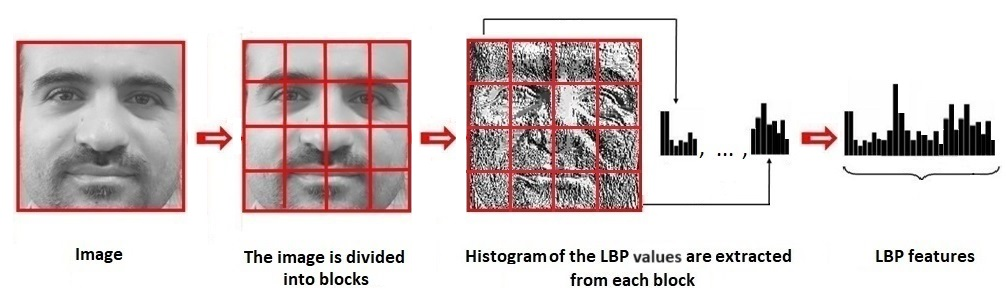

Pixelaufloesung 64 x 64
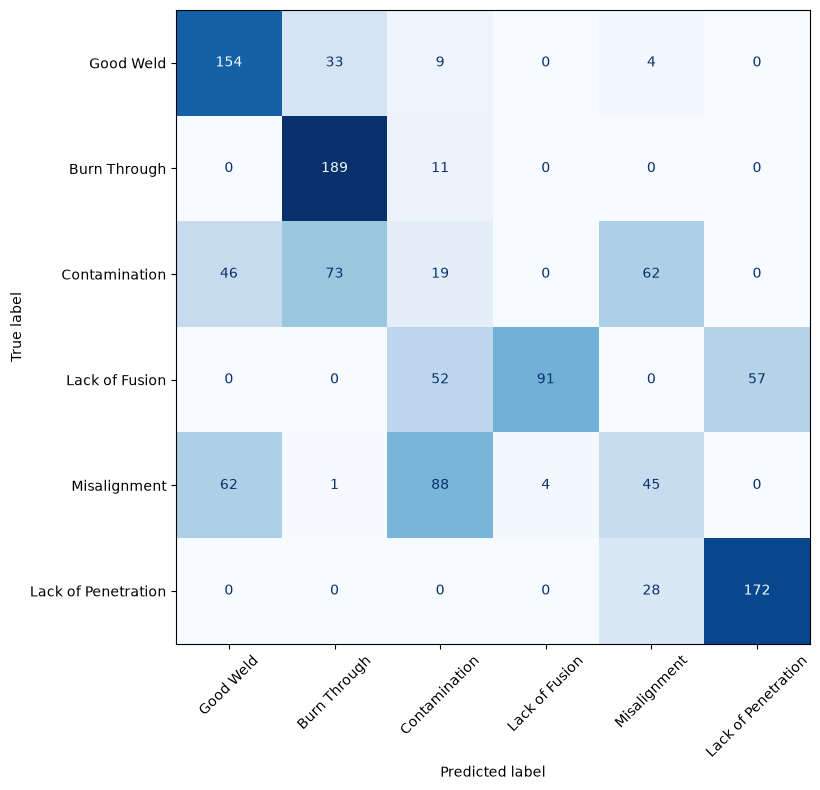